# 01 - Exploratory Data Analysis

**Model objective:** classify task duration into duration buckets, such as Quick, Standard, Extended, or Long-Range, using relevant raw Jira ticket fields.

#### 01-01 Loading Raw Dataset


Load the raw Jira CSV and the plotting tools used throughout this notebook.

- **Pandas** handles tabular inspection and simple feature checks.
- **Matplotlib** provides lightweight plots for quick EDA.

The goal here is not to clean the dataset yet. This notebook identifies the main data-quality issues that the next notebook should handle.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

ticket_df = pd.read_csv('../jira_ticket_dataset.csv')
pd.set_option('display.max_rows', None)

C:\Users\Omar\AppData\Local\Temp\ipykernel_13344\3903141830.py:4: DtypeWarning: Columns (0: customfield_12310921, 1: issuetype.subtask) have mixed types. Specify dtype option on import or set low_memory=False.
  ticket_df = pd.read_csv('../jira_ticket_dataset.csv')


#### 01-02 Dataset Shape Inspection

Start by checking the dataset shape. This confirms the approximate scale of the raw export before selecting features or dropping rows.


In [4]:
ticket_df.shape

(1149323, 37)

*This tells us the raw export has roughly 1.15 million rows and 37 columns.*


Next, review the available columns, non-null counts, and inferred data types. This helps identify which fields are useful for modeling and which fields may need cleaning.


In [ ]:
ticket_df.head().info()

#### 01-03 Raw Feature Inspection

Based on the dataframe inspection, the most relevant raw features to keep for initial modeling are:

- **summary**: ticket title or short task description
- **description**: longer issue details
- **priority.name**: priority category
- **labels**: assigned Jira labels
- **issuetype.description**: description of the issue type
- **issuetype.name**: issue type label
- **issuetype.subtask**: whether the issue is a subtask
- **resolutiondate**: timestamp used to derive duration
- **created**: timestamp used to derive duration

Some raw features will later be transformed into engineered model inputs:

- **summary** and **description** can become text-length or keyword features.
- **labels** can become a label-count feature.
- **resolutiondate** and **created** are used to derive the target duration.


In [6]:
# temporarily only use raw features that will be included in model training

raw_feature_columns = [
    "summary",
    "description",
    "priority.name",
    "labels",
    "issuetype.description",
    "issuetype.name",
    "issuetype.subtask",
    "resolutiondate",
    "created",
]

ticket_df = ticket_df[raw_feature_columns]

#### 01-04 Checking Null and Missing Values

Missing values are one of the first issues to inspect because they determine what can safely move into the cleaning notebook.

For this project, **created**, **resolutiondate**, and **summary** are non-negotiable fields:

- missing **created** or **resolutiondate** means `duration_days` cannot be calculated.
- missing **summary** removes a key text signal for model training.

The next plots show where missingness is concentrated and how much of the dataset is affected.


##### 01-04-01 Missing Value Percentage by Column


This chart highlights which selected raw features have the highest missing-value rates. A high missing percentage does not always mean a column is useless, but it does mean the cleaning notebook must handle that field deliberately.


,missing_count,missing_percent
resolutiondate,202608,17.628465
description,123243,10.723095
priority.name,31859,2.771980
issuetype.description,19259,1.675682
labels,18319,1.593895
summary,18100,1.574840
issuetype.subtask,18099,1.574753
issuetype.name,18099,1.574753
created,18099,1.574753


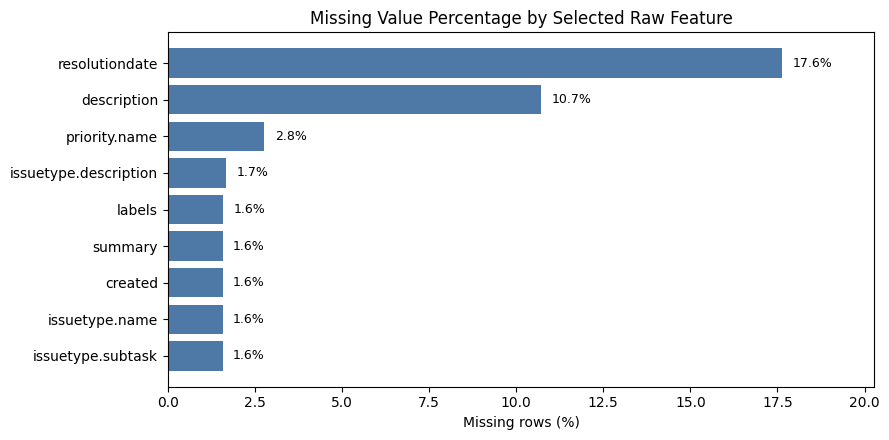

In [26]:
missing_table = pd.DataFrame({
    "missing_count": ticket_df.isna().sum(),
    "missing_percent": ticket_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=True)

display(missing_table.sort_values("missing_percent", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(missing_table.index, missing_table["missing_percent"], color="#4E79A7")
ax.set_title("Missing Value Percentage by Selected Raw Feature")
ax.set_xlabel("Missing rows (%)")
ax.set_ylabel("")
ax.set_xlim(0, max(5, missing_table["missing_percent"].max() * 1.15))

for bar in bars:
    value = bar.get_width()
    if value > 0:
        ax.text(value + 0.3, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


##### 01-04-02 Missingness Pattern Snapshot

The percentage chart shows how much is missing per column, but this matrix shows whether missing values appear in repeated row patterns. This is useful before cleaning because entire groups of rows may be missing the same required fields.


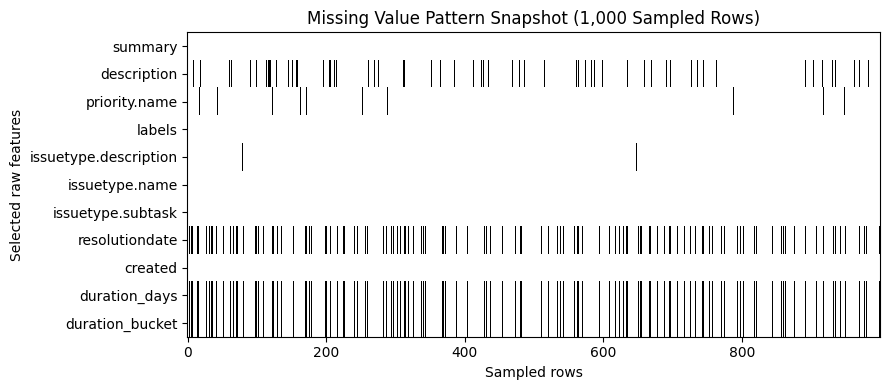

In [ ]:
missing_sample = ticket_df.isna().sample(n=min(1000, len(ticket_df)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 4))
ax.imshow(missing_sample.T, aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_title("Missing Value Pattern Snapshot (1,000 Sampled Rows)")
ax.set_xlabel("Sampled rows")
ax.set_ylabel("Selected raw features")
ax.set_yticks(range(len(missing_sample.columns)))
ax.set_yticklabels(missing_sample.columns)

plt.tight_layout()
plt.show()


##### 01-04-03 Required Field Impact

The next graph focuses only on the fields that must exist before training. These are the rows most likely to be dropped in the cleaning notebook.


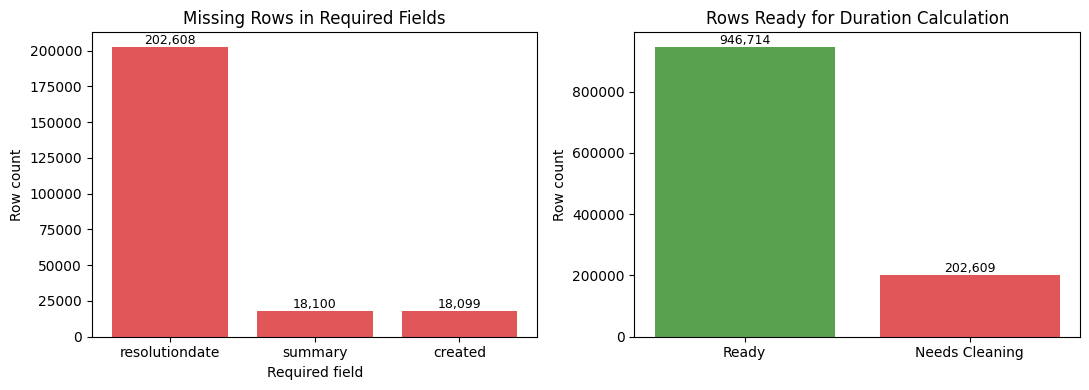

In [8]:
required_columns = ["created", "resolutiondate", "summary"]
required_missing = ticket_df[required_columns].isna().sum().sort_values(ascending=False)
rows_missing_any_required = ticket_df[required_columns].isna().any(axis=1).sum()
rows_ready_for_duration = len(ticket_df) - rows_missing_any_required

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(required_missing.index, required_missing.values, color="#E15759")
axes[0].set_title("Missing Rows in Required Fields")
axes[0].set_xlabel("Required field")
axes[0].set_ylabel("Row count")

for index, value in enumerate(required_missing.values):
    axes[0].text(index, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

axes[1].bar(["Ready", "Needs Cleaning"], [rows_ready_for_duration, rows_missing_any_required], color=["#59A14F", "#E15759"])
axes[1].set_title("Rows Ready for Duration Calculation")
axes[1].set_ylabel("Row count")

for index, value in enumerate([rows_ready_for_duration, rows_missing_any_required]):
    axes[1].text(index, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


##### 01-05 Task Duration Distribution

The main target feature is `duration_days`, calculated as:

`duration_days = resolutiondate - created`

The plot below gives a first look at the planned duration classes. This is still exploratory: the next notebook should remove missing required fields, drop duplicates, convert dates, and check duration outliers more carefully before model training.


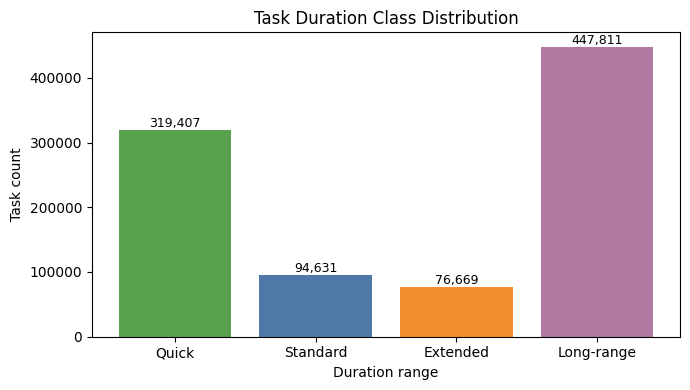

In [30]:
# Basic cleaning only for visualization in this EDA notebook.
# The formal cleaning steps are handled in 02_data_cleaning.ipynb.

cleaned_df = ticket_df.drop_duplicates()
cleaned_df = cleaned_df.dropna(subset=["created", "resolutiondate", "summary"]).copy()

cleaned_df["created"] = pd.to_datetime(cleaned_df["created"], errors="coerce")
cleaned_df["resolutiondate"] = pd.to_datetime(cleaned_df["resolutiondate"], errors="coerce")

cleaned_df["duration_days"] = (cleaned_df["resolutiondate"] - cleaned_df["created"]).dt.total_seconds() / (60 * 60 * 24)
cleaned_df = cleaned_df[cleaned_df["duration_days"].notna() & (cleaned_df["duration_days"] >= 0)]

def duration_range(days):
    if days <= 3:
        return "Quick"
    if days <= 7:
        return "Standard"
    if days <= 14:
        return "Extended"
    return "Long-range"

duration_order = ["Quick", "Standard", "Extended", "Long-range"]
cleaned_df["duration_range"] = cleaned_df["duration_days"].apply(duration_range)
duration_counts = cleaned_df["duration_range"].value_counts().reindex(duration_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(duration_counts.index, duration_counts.values, color=["#59A14F", "#4E79A7", "#F28E2B", "#B07AA1"])
ax.set_title("Task Duration Class Distribution")
ax.set_xlabel("Duration range")
ax.set_ylabel("Task count")

# adds floating max values

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


As seen above, there seems to be skewed data in both ends of bar charts.

Therefore it is better to further visualize the distribution among the ranges to get a better look at how the data is distributed on the day scale.

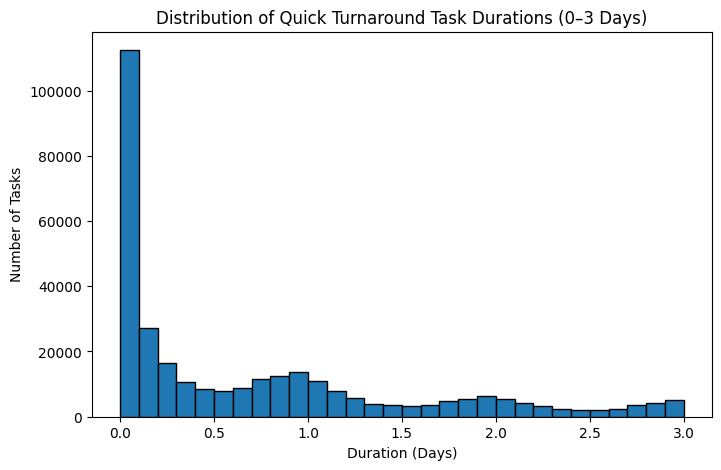

In [ ]:
quick_df = cleaned_df[
    (cleaned_df["duration_days"] >= 0) &
    (cleaned_df["duration_days"] <= 3)
]

plt.figure(figsize=(8, 5))

plt.hist(quick_df["duration_days"], bins=30, edgecolor="black")

plt.title("Distribution of Quick Turnaround Task Durations (0–3 Days)")
plt.xlabel("Duration (Days)")
plt.ylabel("Number of Tasks")

plt.show()


In [39]:
cleaned_df[cleaned_df["duration_days"] <= 0.2].head()

,summary,description,priority.name,labels,issuetype.description,issuetype.name,issuetype.subtask,resolutiondate,created,duration_days,duration_range
0,Update config browser to work with the new syntax,The config browser used Velocity calling the t...,Minor,[],An improvement or enhancement to an existing f...,Improvement,False,2005-01-01 07:50:46,2005-01-01 07:47:50,0.002037,Quick
7,Port changes from tomcat-catalina,Since the [naming] sources were extracted from...,Major,[],A problem which impairs or prevents the functi...,Bug,False,2005-01-03 11:38:03,2005-01-03 11:16:07,0.015231,Quick
12,old 2.08 DTD at http://www.ibatis.com/dtd/sql-...,The public DTD has no elements allowing inclus...,Major,[],A problem which impairs or prevents the functi...,Bug,False,2005-01-04 01:35:21,2005-01-03 21:29:08,0.170984,Quick
14,DataMapper.Configuration.SqlGenerator.BuildDel...,Minor issue with quick fix.\n\nGenerated DELET...,Minor,[],A problem which impairs or prevents the functi...,Bug,False,2005-01-04 06:05:56,2005-01-04 04:26:11,0.069271,Quick
17,variable name clash in macro,The LOG4CXX macros use a temporary ostringstre...,Trivial,[],A problem which impairs or prevents the functi...,Bug,False,2005-01-04 13:28:40,2005-01-04 10:39:02,0.117801,Quick


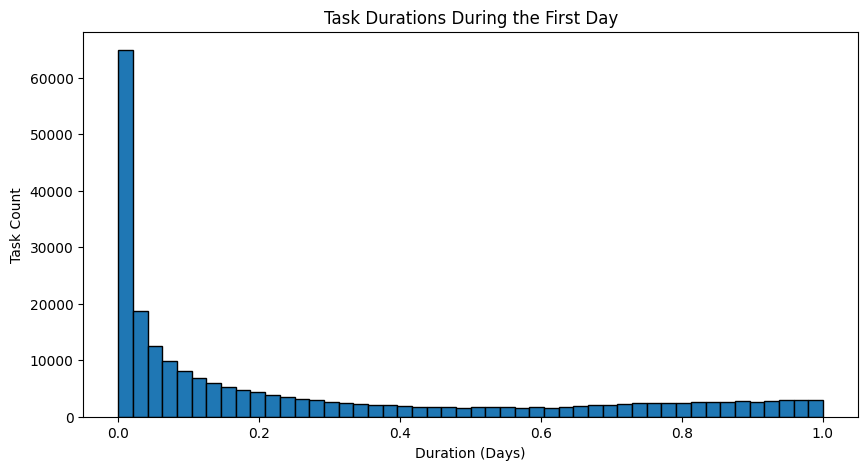

In [38]:
plt.figure(figsize=(10,5))

plt.hist(
    quick_df["duration_days"],
    bins=48,          # 30-minute bins
    range=(0,1),
    edgecolor="black"
)

plt.title("Task Durations During the First Day")
plt.xlabel("Duration (Days)")
plt.ylabel("Task Count")

plt.show()